Gerando Perfil IGC (PT)...


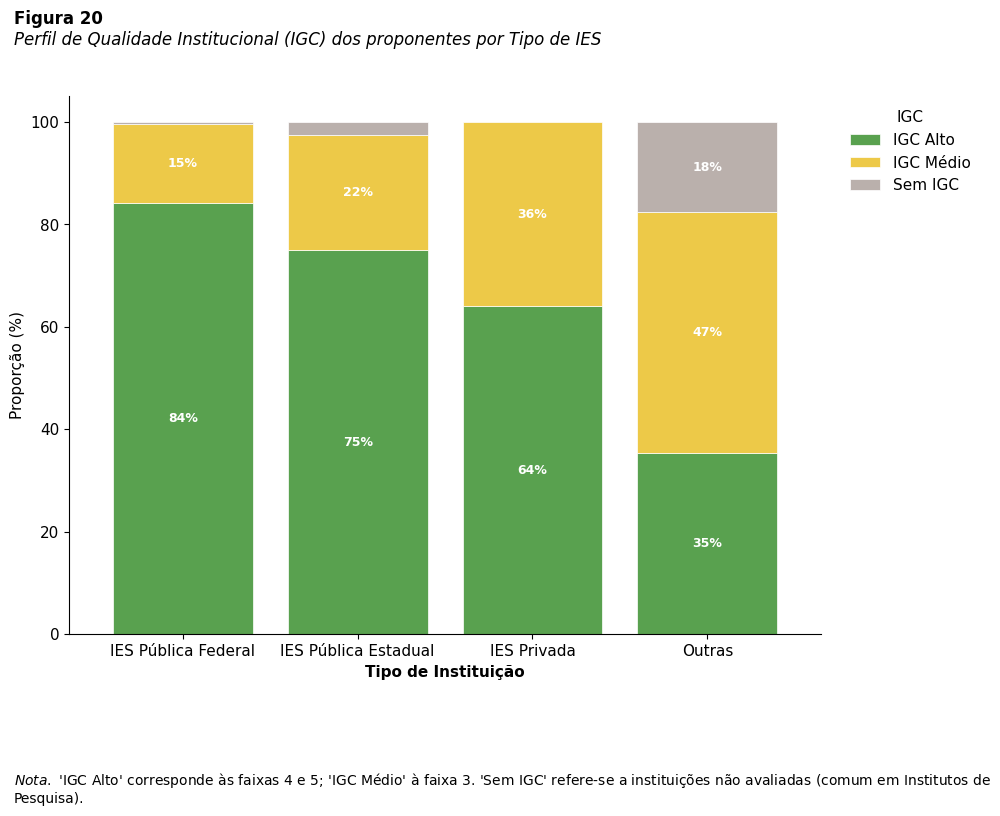

Gerando Perfil IGC (EN)...


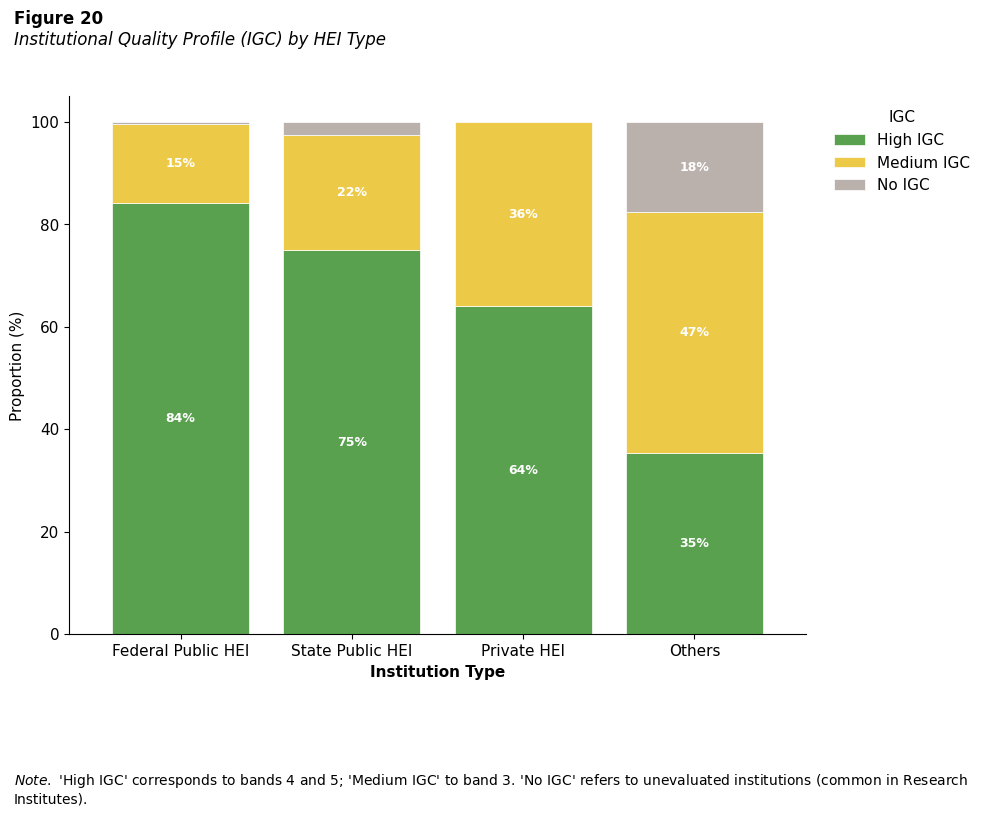

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'

# Filtro: Remover nulos se houver
df = df.dropna(subset=[col_igc, col_inst])

# Mapeamentos para Inglês
mapa_inst_en = {
    'IES Pública Federal': 'Federal Public HEI',
    'IES Pública Estadual': 'State Public HEI',
    'IES Privada': 'Private HEI',
    'Instituto de Pesquisa': 'Research Institute',
    'Outras': 'Others'
}
mapa_igc_en = {
    'IGC Alto': 'High IGC',
    'IGC Médio': 'Medium IGC',
    'Sem IGC': 'No IGC'
}

df['inst_en'] = df[col_inst].map(mapa_inst_en)
df['igc_en'] = df[col_igc].map(mapa_igc_en)

# Cores semânticas para Qualidade
# Alto = Verde, Médio = Amarelo/Laranja, Sem IGC = Cinza
colors_igc = {
    'IGC Alto': '#59a14f', 'High IGC': '#59a14f',
    'IGC Médio': '#edc948', 'Medium IGC': '#edc948',
    'Sem IGC': '#bab0ac', 'No IGC': '#bab0ac'
}

# ==============================================================================
# FUNÇÃO DE PLOTAGEM (BARRAS EMPILHADAS)
# ==============================================================================
def plot_igc_profile(lang='pt'):
    c_inst = col_inst if lang == 'pt' else 'inst_en'
    c_igc = col_igc if lang == 'pt' else 'igc_en'

    # Crosstab normalizado
    ct = pd.crosstab(df[c_inst], df[c_igc], normalize='index') * 100

    # Ordenar colunas de IGC (Alto -> Médio -> Sem IGC)
    ordem_igc_pt = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ordem_igc_en = ['High IGC', 'Medium IGC', 'No IGC']
    ordem = ordem_igc_pt if lang == 'pt' else ordem_igc_en
    ct = ct.reindex(columns=[c for c in ordem if c in ct.columns]) # Reindex seguro

    # Ordenar linhas (Instituições) para agrupar Federais perto de Estaduais
    ordem_inst_pt = ['IES Pública Federal', 'IES Pública Estadual', 'IES Privada', 'Outras']
    ordem_inst_en = ['Federal Public HEI', 'State Public HEI', 'Private HEI', 'Others']
    ordem_i = ordem_inst_pt if lang == 'pt' else ordem_inst_en
    ct = ct.reindex([c for c in ordem_i if c in ct.index])

    fig, ax = plt.subplots(figsize=(10, 7))

    color_list = [colors_igc.get(c, '#bab0ac') for c in ct.columns]
    ct.plot(kind='bar', stacked=True, width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Rótulos
    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    # Textos
    if lang == 'pt':
        ax.set_xlabel("Tipo de Instituição", weight='bold')
        ax.set_ylabel("Proporção (%)")
        title = "Perfil de Qualidade Institucional (IGC) dos proponentes por Tipo de IES"
        fignum = "Figura 20"
        note = (r"$\it{Nota.}$ 'IGC Alto' corresponde às faixas 4 e 5; 'IGC Médio' à faixa 3. "
                "'Sem IGC' refere-se a instituições não avaliadas (comum em Institutos de Pesquisa).")
    else:
        ax.set_xlabel("Institution Type", weight='bold')
        ax.set_ylabel("Proportion (%)")
        title = "Institutional Quality Profile (IGC) by HEI Type"
        fignum = "Figure 20"
        note = (r"$\it{Note.}$ 'High IGC' corresponds to bands 4 and 5; 'Medium IGC' to band 3. "
                "'No IGC' refers to unevaluated institutions (common in Research Institutes).")

    plt.xticks(rotation=0, ha='center')
    ax.legend(title="IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.96, fignum, fontsize=12, weight='bold')
    fig.text(0.02, 0.93, title, fontsize=12, style='italic')
    fig.text(0.02, -0.15, note, fontsize=10, ha='left', wrap=True) # Espaço extra para nota

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.savefig(f"apa_fig20_igc_profile_{lang}.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Perfil IGC (PT)...")
plot_igc_profile('pt')
print("Gerando Perfil IGC (EN)...")
plot_igc_profile('en')

Gerando Gráficos Filtrados (PT)...


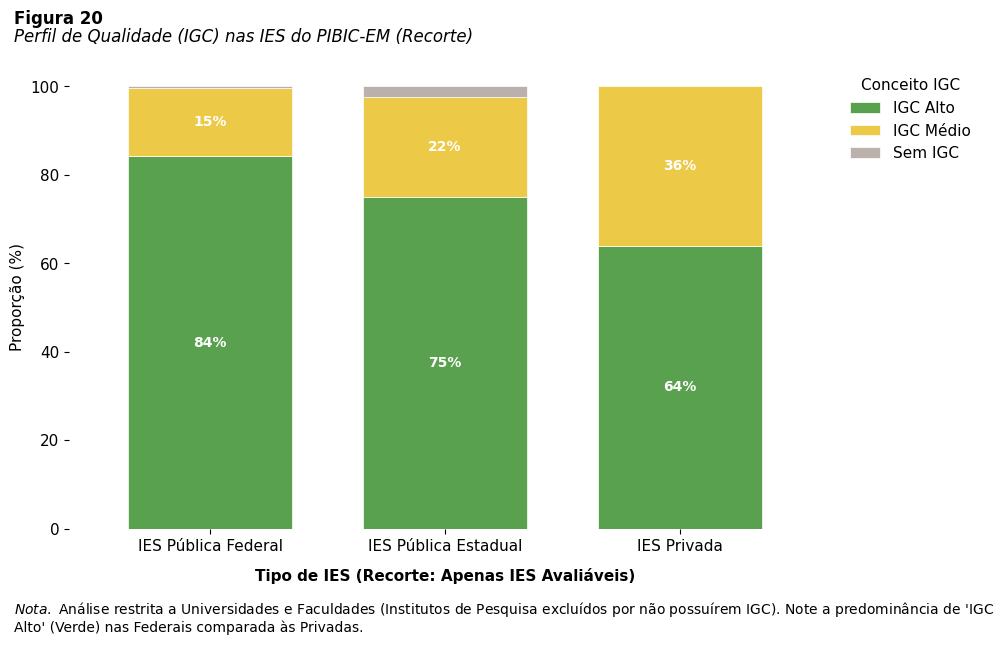

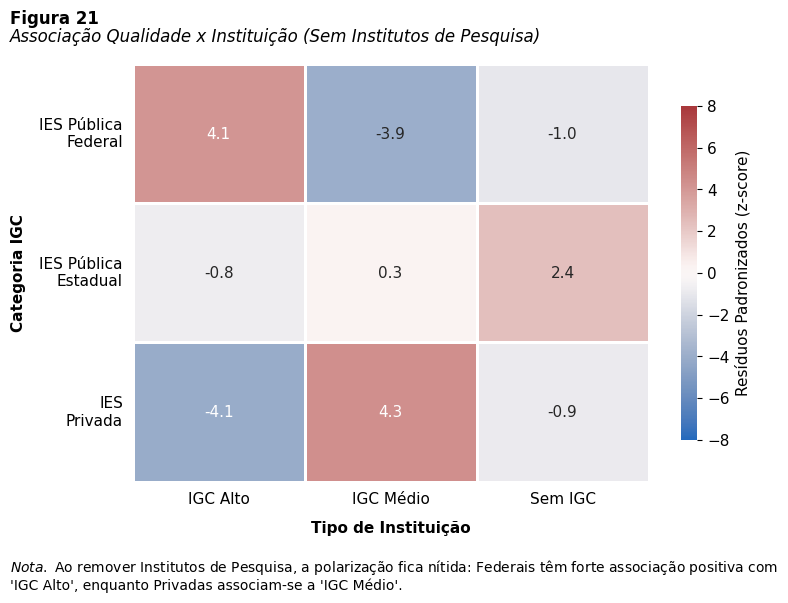

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False   # Limpo para Heatmap
rcParams['axes.spines.bottom'] = False # Limpo para Heatmap
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS E FILTRAGEM (O PULO DO GATO)
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'

# 1. Remover nulos básicos
df = df.dropna(subset=[col_igc, col_inst])

# 2. FILTRO ESTRATÉGICO: Remover Institutos e Outras
categorias_para_remover = ['Instituto de Pesquisa', 'Outras']
df_filtered = df[~df[col_inst].isin(categorias_para_remover)].copy()

# ==============================================================================
# PLOT 1: BARRAS EMPILHADAS (PERFIL COMPARÁVEL)
# ==============================================================================
def plot_igc_bars_filtered_pt():
    # Crosstab normalizado
    ct = pd.crosstab(df_filtered[col_inst], df_filtered[col_igc], normalize='index') * 100

    # Ordenação IGC e Instituição
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    # Ordenar Instituições (Agora só restam 3)
    ordem_inst = ['IES Pública Federal', 'IES Pública Estadual', 'IES Privada']
    ct = ct.reindex([c for c in ordem_inst if c in ct.index])

    fig, ax = plt.subplots(figsize=(10, 6))

    colors_igc = {'IGC Alto': '#59a14f', 'IGC Médio': '#edc948', 'Sem IGC': '#bab0ac'}
    color_list = [colors_igc.get(c) for c in ct.columns]

    ct.plot(kind='bar', stacked=True, width=0.7, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Rótulos
    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

    ax.set_xlabel("Tipo de IES (Recorte: Apenas IES Avaliáveis)", weight='bold', labelpad=10)
    ax.set_ylabel("Proporção (%)")
    plt.xticks(rotation=0, ha='center')

    # Legenda e Nota
    ax.legend(title="Conceito IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.96, "Figura 20", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Perfil de Qualidade (IGC) nas IES do PIBIC-EM (Recorte)", fontsize=12, style='italic')
    note = (r"$\it{Nota.}$ Análise restrita a Universidades e Faculdades (Institutos de Pesquisa excluídos por não possuírem IGC). "
            "Note a predominância de 'IGC Alto' (Verde) nas Federais comparada às Privadas.")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig20_igc_filtered_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# PLOT 2: HEATMAP DE RESÍDUOS (A VERDADEIRA DISPUTA)
# ==============================================================================
def plot_igc_heatmap_filtered_pt():
    # Recalcular crosstab apenas com os filtrados
    ct = pd.crosstab(df_filtered[col_igc], df_filtered[col_inst])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)

    # Recalcular resíduos (Agora o "Esperado" muda, pois tiramos os Institutos!)
    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        residuos = (observed - expected) / div

    df_res = pd.DataFrame(residuos, index=ct.index, columns=ct.columns).fillna(0)

    # Ordenação
    ordem_inst = ['IES Pública Federal', 'IES Pública Estadual', 'IES Privada']
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']

    # Mapear nomes para quebra de linha
    mapa_inst = {
        'IES Pública Federal': 'IES Pública\nFederal',
        'IES Pública Estadual': 'IES Pública\nEstadual',
        'IES Privada': 'IES\nPrivada'
    }
    df_res = df_res.rename(columns=mapa_inst)
    ordem_inst_mapped = [mapa_inst[i] for i in ordem_inst if i in mapa_inst]

    # Filtrar e Ordenar (Transposto: Inst no X, IGC no Y)
    df_res = df_res.loc[ordem_igc, ordem_inst_mapped].T

    fig, ax = plt.subplots(figsize=(8, 6))

    # Heatmap (Escala normalizada agora que tiramos o outlier +21)
    sns.heatmap(df_res, annot=True, fmt=".1f", cmap="vlag", center=0, vmin=-8, vmax=8,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados (z-score)', 'shrink': 0.8}, ax=ax)

    ax.set_xlabel("Tipo de Instituição", weight='bold', labelpad=10)
    ax.set_ylabel("Categoria IGC", weight='bold', labelpad=10)
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    ax.tick_params(left=False, bottom=False)

    fig.text(0.02, 0.96, "Figura 21", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Associação Qualidade x Instituição (Sem Institutos de Pesquisa)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Ao remover Institutos de Pesquisa, a polarização fica nítida: "
            "Federais têm forte associação positiva com 'IGC Alto', enquanto Privadas associam-se a 'IGC Médio'.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig21_heatmap_igc_filtered_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Gráficos Filtrados (PT)...")
plot_igc_bars_filtered_pt()
plot_igc_heatmap_filtered_pt()

Gerando Gráficos Filtrados (EN)...


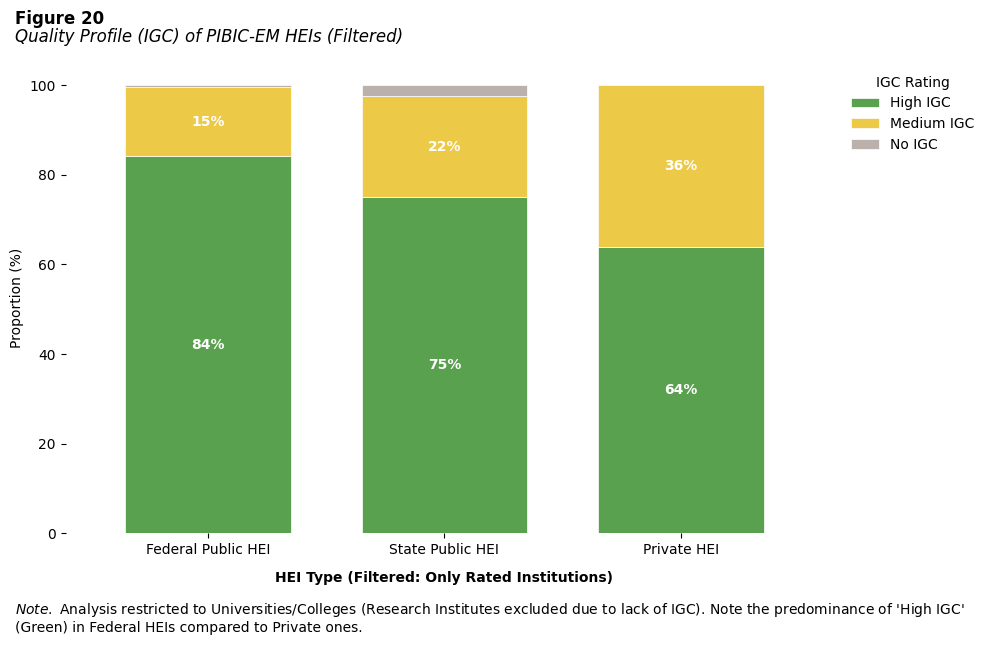

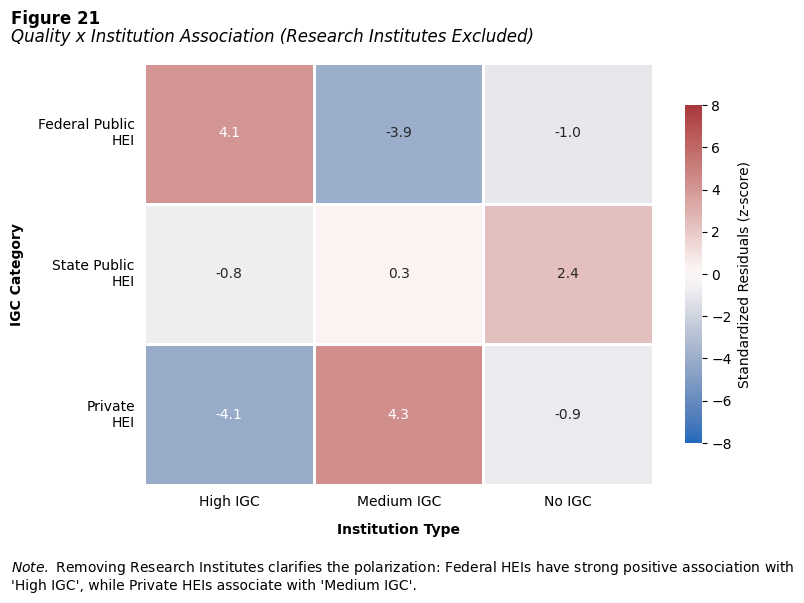

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    df = df.dropna(subset=['igc_categoria', 'tipo_ies_corrigido'])

    # Filter
    exclude = ['Instituto de Pesquisa', 'Outras']
    df_filtered = df[~df['tipo_ies_corrigido'].isin(exclude)].copy()
except:
    df_filtered = pd.DataFrame()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Federal Public HEI',
    'IES Pública Estadual': 'State Public HEI',
    'IES Privada': 'Private HEI'
}
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}

df_filtered['inst_en'] = df_filtered['tipo_ies_corrigido'].map(mapa_inst_en)
df_filtered['igc_en'] = df_filtered['igc_categoria'].map(mapa_igc_en)

# ------------------------------------------------------------------------------
# PLOT 1: BARS (EN)
# ------------------------------------------------------------------------------
def plot_igc_bars_filtered_en():
    ct = pd.crosstab(df_filtered['inst_en'], df_filtered['igc_en'], normalize='index') * 100

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    ordem_inst = ['Federal Public HEI', 'State Public HEI', 'Private HEI']
    ct = ct.reindex([c for c in ordem_inst if c in ct.index])

    fig, ax = plt.subplots(figsize=(10, 6))
    colors_igc = {'High IGC': '#59a14f', 'Medium IGC': '#edc948', 'No IGC': '#bab0ac'}
    color_list = [colors_igc.get(c) for c in ct.columns]

    ct.plot(kind='bar', stacked=True, width=0.7, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')

    ax.set_xlabel("HEI Type (Filtered: Only Rated Institutions)", weight='bold', labelpad=10)
    ax.set_ylabel("Proportion (%)")
    plt.xticks(rotation=0, ha='center')
    ax.legend(title="IGC Rating", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.96, "Figure 20", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Quality Profile (IGC) of PIBIC-EM HEIs (Filtered)", fontsize=12, style='italic')
    note = (r"$\it{Note.}$ Analysis restricted to Universities/Colleges (Research Institutes excluded due to lack of IGC). "
            "Note the predominance of 'High IGC' (Green) in Federal HEIs compared to Private ones.")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig20_igc_filtered_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

# ------------------------------------------------------------------------------
# PLOT 2: HEATMAP (EN)
# ------------------------------------------------------------------------------
def plot_igc_heatmap_filtered_en():
    ct = pd.crosstab(df_filtered['igc_en'], df_filtered['inst_en'])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)

    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        residuos = (observed - expected) / div

    df_res = pd.DataFrame(residuos, index=ct.index, columns=ct.columns).fillna(0)

    ordem_inst = ['Federal Public HEI', 'State Public HEI', 'Private HEI']
    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']

    mapa_break = {'Federal Public HEI': 'Federal Public\nHEI', 'State Public HEI': 'State Public\nHEI', 'Private HEI': 'Private\nHEI'}
    df_res = df_res.rename(columns=mapa_break)
    ordem_inst_mapped = [mapa_break[i] for i in ordem_inst]

    df_res = df_res.loc[ordem_igc, ordem_inst_mapped].T

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(df_res, annot=True, fmt=".1f", cmap="vlag", center=0, vmin=-8, vmax=8,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Standardized Residuals (z-score)', 'shrink': 0.8}, ax=ax)

    ax.set_xlabel("Institution Type", weight='bold', labelpad=10)
    ax.set_ylabel("IGC Category", weight='bold', labelpad=10)
    plt.xticks(rotation=0, ha='center')
    plt.yticks(rotation=0)
    ax.tick_params(left=False, bottom=False)

    fig.text(0.02, 0.96, "Figure 21", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Quality x Institution Association (Research Institutes Excluded)", fontsize=12, style='italic')
    note = (r"$\it{Note.}$ Removing Research Institutes clarifies the polarization: "
            "Federal HEIs have strong positive association with 'High IGC', while Private HEIs associate with 'Medium IGC'.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig21_heatmap_igc_filtered_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Gráficos Filtrados (EN)...")
plot_igc_bars_filtered_en()
plot_igc_heatmap_filtered_en()

Gerando Mosaico IGC (PT)...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


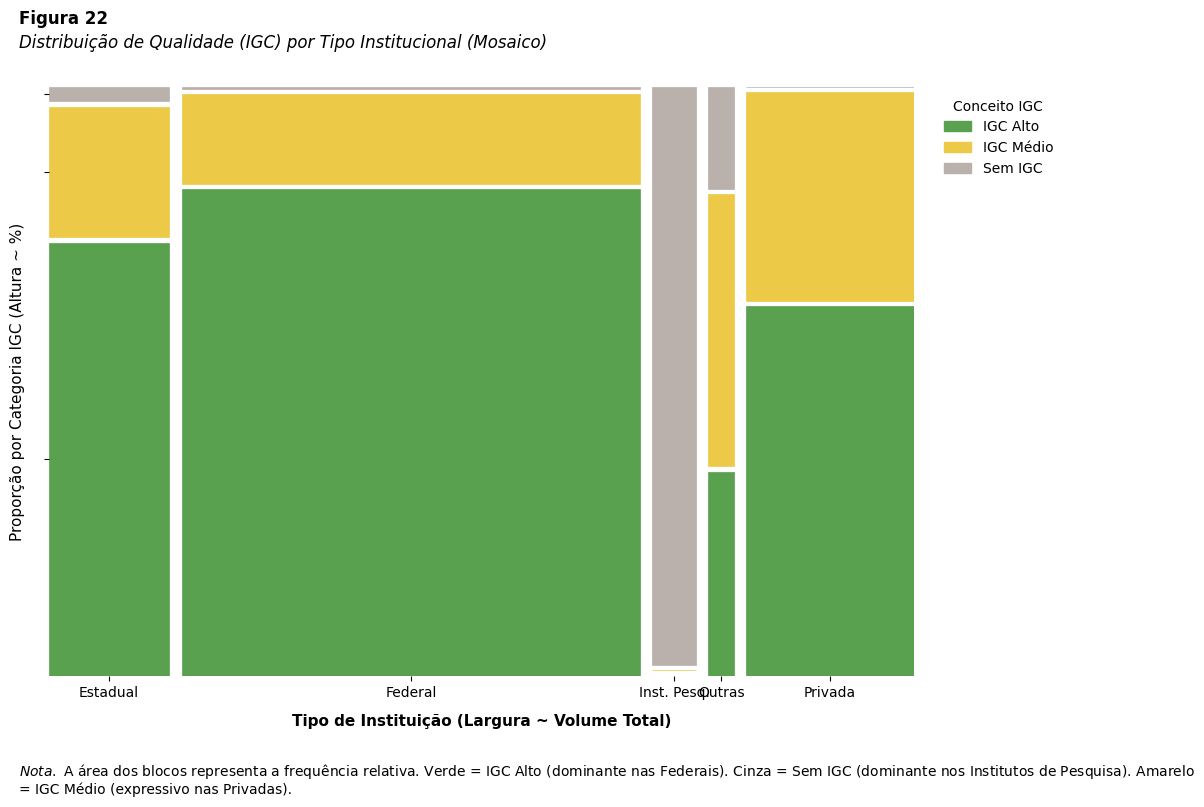

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.patches as mpatches
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'
df = df.dropna(subset=[col_igc, col_inst])

# Mapeamentos PT (Nomes Curtos para o Eixo X)
mapa_inst_pt = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'Estadual',
    'IES Privada': 'Privada',
    'Instituto de Pesquisa': 'Inst. Pesq.',
    'Outras': 'Outras'
}
# Mapeamento IGC (Para ordem lógica)
# Vamos transformar em categórica ordenada
ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']

df['inst_pt'] = df[col_inst].map(mapa_inst_pt)
df['igc_cat'] = pd.Categorical(df[col_igc], categories=ordem_igc, ordered=True)

# Ordenar DF para o plot ficar organizado (Alto embaixo ou em cima)
df = df.sort_values(['inst_pt', 'igc_cat'])

# Cores baseadas no IGC (A "qualidade" pinta o gráfico)
colors_igc = {
    'IGC Alto': '#59a14f',   # Verde (Excelência)
    'IGC Médio': '#edc948',  # Amarelo (Médio)
    'Sem IGC': '#bab0ac'     # Cinza (Neutro/Ausente)
}

# ==============================================================================
# PLOTAGEM (PORTUGUÊS)
# ==============================================================================
def plot_mosaic_igc_pt():
    fig, ax = plt.subplots(figsize=(12, 8))

    # Função que define a cor baseada na chave (Instituição, IGC)
    def props(key):
        # key[1] é a categoria de IGC
        return {'color': colors_igc.get(key[1], '#bab0ac'), 'edgecolor': 'white', 'linewidth': 0.5}

    # Plot
    # Index: [Eixo X, Eixo Y] -> [Instituição, IGC]
    mosaic(df, index=['inst_pt', 'igc_cat'], ax=ax, properties=props, gap=0.015, labelizer=lambda k: "")

    # Eixos
    ax.set_xlabel("Tipo de Instituição (Largura ~ Volume Total)", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proporção por Categoria IGC (Altura ~ %)", fontsize=11, labelpad=10)

    # Limpar labels do eixo Y (pois a legenda já explica as cores)
    ax.set_yticklabels([])

    # Ajustar labels do eixo X (Rotação se necessário)
    for label in ax.get_xticklabels():
        label.set_rotation(0)

    # Legenda Manual
    patches = [mpatches.Patch(color=colors_igc[l], label=l) for l in ordem_igc]
    ax.legend(handles=patches, title="Conceito IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Cabeçalho e Nota APA
    fig.text(0.02, 0.98, "Figura 22", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Distribuição de Qualidade (IGC) por Tipo Institucional (Mosaico)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ A área dos blocos representa a frequência relativa. "
            "Verde = IGC Alto (dominante nas Federais). Cinza = Sem IGC (dominante nos Institutos de Pesquisa). "
            "Amarelo = IGC Médio (expressivo nas Privadas).")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 0.9, 0.92])
    plt.savefig("apa_fig22_mosaic_igc_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Mosaico IGC (PT)...")
plot_mosaic_igc_pt()

Gerando Mosaico IGC (EN)...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


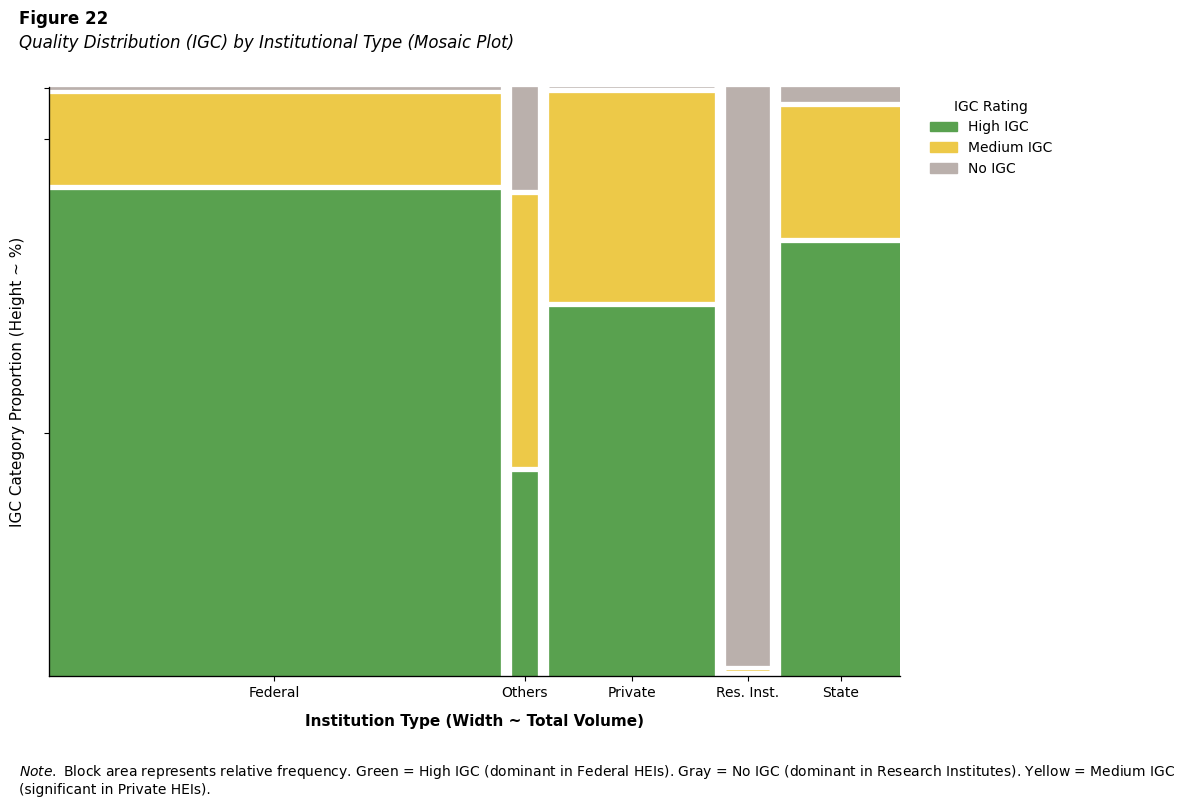

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.patches as mpatches
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
    col_igc = 'igc_categoria'
    col_inst = 'tipo_ies_corrigido'
    df = df.dropna(subset=[col_igc, col_inst])
except:
    df = pd.DataFrame()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'State',
    'IES Privada': 'Private',
    'Instituto de Pesquisa': 'Res. Inst.',
    'Outras': 'Others'
}
mapa_igc_en = {
    'IGC Alto': 'High IGC',
    'IGC Médio': 'Medium IGC',
    'Sem IGC': 'No IGC'
}

df['inst_en'] = df[col_inst].map(mapa_inst_en)
df['igc_en'] = df[col_igc].map(mapa_igc_en)

# Ordem Lógica
ordem_igc_en = ['High IGC', 'Medium IGC', 'No IGC']
df['igc_cat_en'] = pd.Categorical(df['igc_en'], categories=ordem_igc_en, ordered=True)
df = df.sort_values(['inst_en', 'igc_cat_en'])

# Cores
colors_igc_en = {
    'High IGC': '#59a14f',   # Green
    'Medium IGC': '#edc948', # Yellow
    'No IGC': '#bab0ac'      # Gray
}

def plot_mosaic_igc_en():
    fig, ax = plt.subplots(figsize=(12, 8))

    def props(key):
        return {'color': colors_igc_en.get(key[1], '#bab0ac'), 'edgecolor': 'white', 'linewidth': 0.5}

    mosaic(df, index=['inst_en', 'igc_cat_en'], ax=ax, properties=props, gap=0.015, labelizer=lambda k: "")

    ax.set_xlabel("Institution Type (Width ~ Total Volume)", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("IGC Category Proportion (Height ~ %)", fontsize=11, labelpad=10)
    ax.set_yticklabels([])

    for label in ax.get_xticklabels():
        label.set_rotation(0)

    patches = [mpatches.Patch(color=colors_igc_en[l], label=l) for l in ordem_igc_en]
    ax.legend(handles=patches, title="IGC Rating", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figure 22", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Quality Distribution (IGC) by Institutional Type (Mosaic Plot)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Block area represents relative frequency. "
            "Green = High IGC (dominant in Federal HEIs). Gray = No IGC (dominant in Research Institutes). "
            "Yellow = Medium IGC (significant in Private HEIs).")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 0.9, 0.92])
    plt.savefig("apa_fig22_mosaic_igc_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Mosaico IGC (EN)...")
plot_mosaic_igc_en()

Gerando Grouped Bars IGC (PT)...


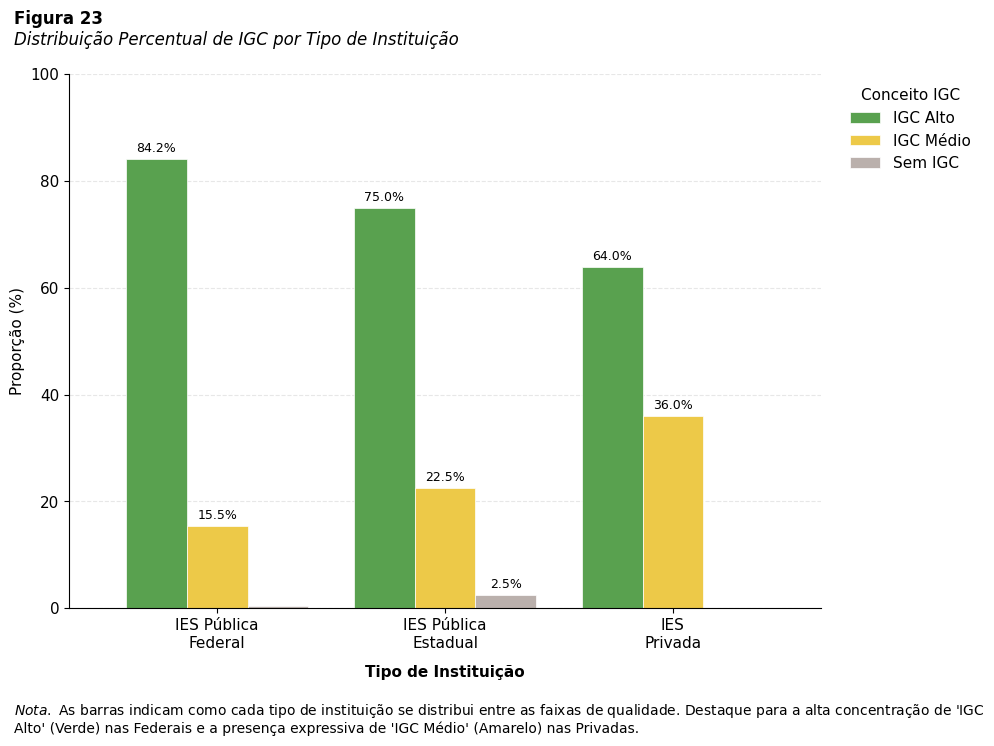

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'

# Filtros: Apenas IES válidas e avaliáveis
df = df.dropna(subset=[col_igc, col_inst])
exclude = ['Instituto de Pesquisa', 'Outras']
df_filtered = df[~df[col_inst].isin(exclude)].copy()

# ==============================================================================
# PLOTAGEM (PORTUGUÊS)
# ==============================================================================
def plot_dodged_igc_pt():
    # Mapeamento para nomes com quebra de linha (para caber no eixo X)
    mapa_inst = {
        'IES Pública Federal': 'IES Pública\nFederal',
        'IES Pública Estadual': 'IES Pública\nEstadual',
        'IES Privada': 'IES\nPrivada'
    }
    df_filtered['inst_plot'] = df_filtered[col_inst].map(mapa_inst)

    # Crosstab normalizado por linha (Instituição = 100%)
    ct = pd.crosstab(df_filtered['inst_plot'], df_filtered[col_igc], normalize='index') * 100

    # Ordenar colunas (IGC) e linhas (Instituições)
    ordem_igc = ['IGC Alto', 'IGC Médio', 'Sem IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    ordem_inst = ['IES Pública\nFederal', 'IES Pública\nEstadual', 'IES\nPrivada']
    ct = ct.reindex([i for i in ordem_inst if i in ct.index])

    fig, ax = plt.subplots(figsize=(10, 7))

    # Cores Semânticas
    colors = {'IGC Alto': '#59a14f', 'IGC Médio': '#edc948', 'Sem IGC': '#bab0ac'}
    color_list = [colors.get(c) for c in ct.columns]

    # Plot Grouped Bars
    ct.plot(kind='bar', width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Rótulos nas barras
    for c in ax.containers:
        # Rótulo vertical se a barra for alta o suficiente, senão horizontal acima
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3, color='black')

    # Ajustes
    ax.set_xlabel("Tipo de Instituição", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proporção (%)", fontsize=11)
    ax.set_ylim(0, 100) # Fixar em 100% para facilitar comparação visual
    plt.xticks(rotation=0, ha='center')

    # Grid leve para leitura
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    ax.legend(title="Conceito IGC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Cabeçalho e Nota
    fig.text(0.02, 0.96, "Figura 23", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Distribuição Percentual de IGC por Tipo de Instituição", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ As barras indicam como cada tipo de instituição se distribui entre as faixas de qualidade. "
            "Destaque para a alta concentração de 'IGC Alto' (Verde) nas Federais e a presença expressiva de 'IGC Médio' (Amarelo) nas Privadas.")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig23_dodged_igc_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Grouped Bars IGC (PT)...")
plot_dodged_igc_pt()

Gerando Grouped Bars IGC (EN)...


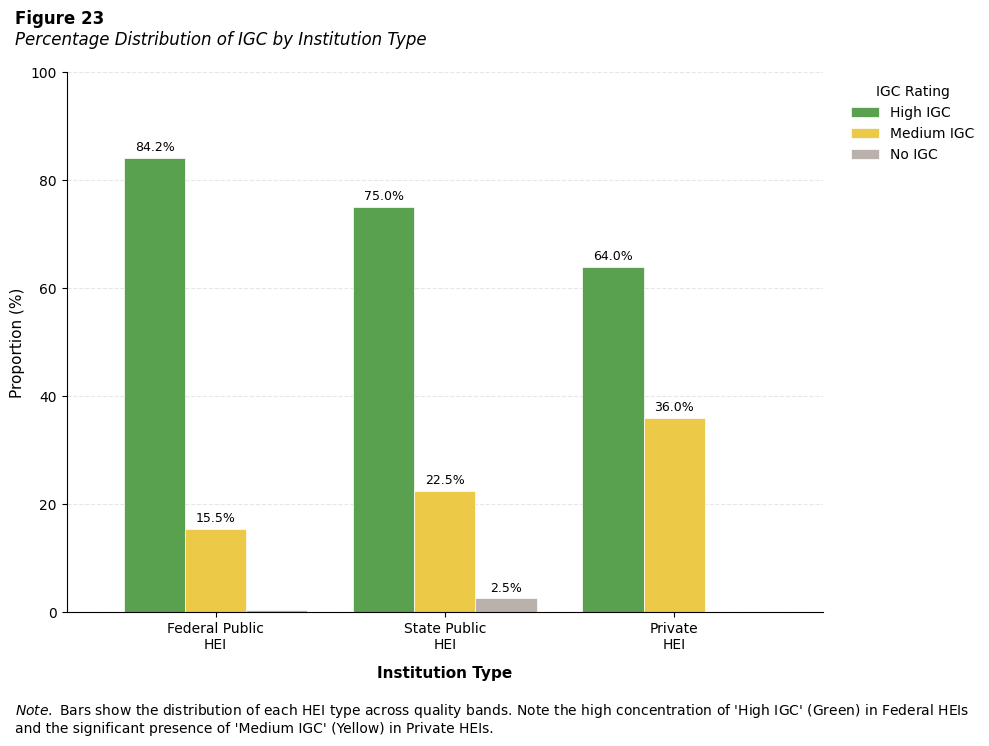

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
    df = df.dropna(subset=['igc_categoria', 'tipo_ies_corrigido'])
    exclude = ['Instituto de Pesquisa', 'Outras']
    df_filtered = df[~df['tipo_ies_corrigido'].isin(exclude)].copy()
except:
    df_filtered = pd.DataFrame()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Federal Public\nHEI',
    'IES Pública Estadual': 'State Public\nHEI',
    'IES Privada': 'Private\nHEI'
}
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}

df_filtered['inst_en'] = df_filtered['tipo_ies_corrigido'].map(mapa_inst_en)
df_filtered['igc_en'] = df_filtered['igc_categoria'].map(mapa_igc_en)

# ==============================================================================
# PLOTAGEM (INGLÊS)
# ==============================================================================
def plot_dodged_igc_en():
    ct = pd.crosstab(df_filtered['inst_en'], df_filtered['igc_en'], normalize='index') * 100

    ordem_igc = ['High IGC', 'Medium IGC', 'No IGC']
    ct = ct.reindex(columns=[c for c in ordem_igc if c in ct.columns])

    ordem_inst = ['Federal Public\nHEI', 'State Public\nHEI', 'Private\nHEI']
    ct = ct.reindex([i for i in ordem_inst if i in ct.index])

    fig, ax = plt.subplots(figsize=(10, 7))

    colors = {'High IGC': '#59a14f', 'Medium IGC': '#edc948', 'No IGC': '#bab0ac'}
    color_list = [colors.get(c) for c in ct.columns]

    ct.plot(kind='bar', width=0.8, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    for c in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3, color='black')

    ax.set_xlabel("Institution Type", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proportion (%)", fontsize=11)
    ax.set_ylim(0, 100)
    plt.xticks(rotation=0, ha='center')

    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    ax.legend(title="IGC Rating", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.96, "Figure 23", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Percentage Distribution of IGC by Institution Type", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Bars show the distribution of each HEI type across quality bands. "
            "Note the high concentration of 'High IGC' (Green) in Federal HEIs and the significant presence of 'Medium IGC' (Yellow) in Private HEIs.")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig23_dodged_igc_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Grouped Bars IGC (EN)...")
plot_dodged_igc_en()

Gerando Radar IGC (PT)...


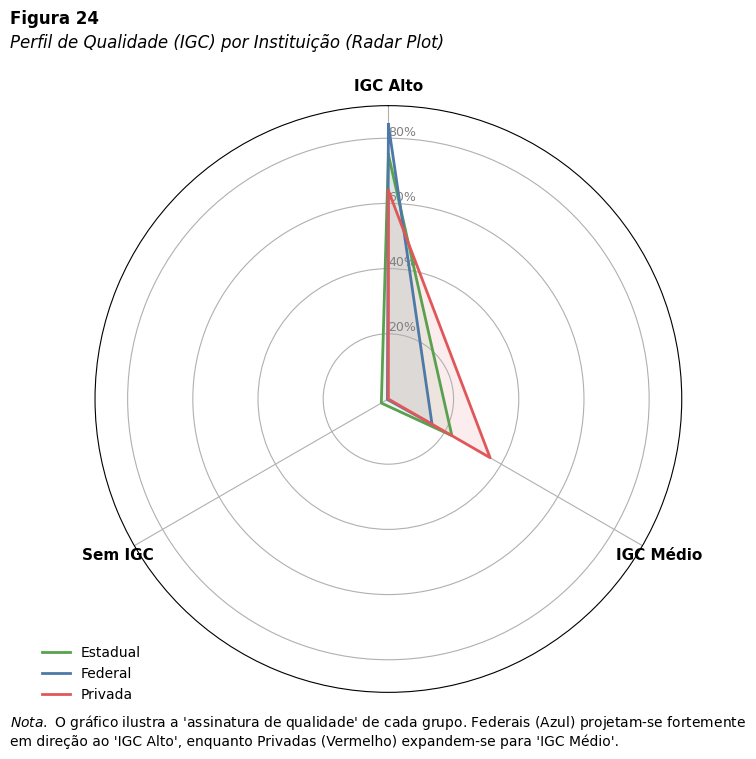

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from math import pi

# Configuração Estética
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# Dados
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'

# Filtros (Mantendo a coerência: apenas IES avaliáveis para comparação justa)
df = df.dropna(subset=[col_igc, col_inst])
exclude = ['Instituto de Pesquisa', 'Outras']
df_filtered = df[~df[col_inst].isin(exclude)].copy()

# Mapeamentos PT
mapa_inst_pt = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'Estadual',
    'IES Privada': 'Privada'
}
df_filtered['inst_pt'] = df_filtered[col_inst].map(mapa_inst_pt)

# Cores
colors = {'Federal': '#4e79a7', 'Estadual': '#59a14f', 'Privada': '#e15759'}

# Preparação do Radar
# Crosstab normalizado (Perfil %)
perfil = pd.crosstab(df_filtered['inst_pt'], df_filtered[col_igc], normalize='index') * 100

# Ordenar Eixos (IGC)
categorias = ['IGC Alto', 'IGC Médio', 'Sem IGC']
perfil = perfil.reindex(columns=categorias)

# Configuração dos Ângulos
N = len(categorias)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Fechar o ciclo

# Função de Plotagem
def plot_radar_igc_pt():
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Ajuste de rotação (12 horas)
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Eixos X
    plt.xticks(angles[:-1], categorias, fontsize=11, weight='bold')

    # Eixo Y (Grid)
    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80], ["20%", "40%", "60%", "80%"], color="grey", size=9)
    plt.ylim(0, 90) # Até 90% pois Federais têm 84% em Alto

    # Plotar Linhas
    for inst in perfil.index:
        values = perfil.loc[inst].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=inst, color=colors[inst])
        ax.fill(angles, values, color=colors[inst], alpha=0.1)

    # Legenda
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), frameon=False)

    # Texto APA
    fig.text(0.05, 0.95, "Figura 24", fontsize=12, weight='bold')
    fig.text(0.05, 0.92, "Perfil de Qualidade (IGC) por Instituição (Radar Plot)", fontsize=12, style='italic')
    note = (r"$\it{Nota.}$ O gráfico ilustra a 'assinatura de qualidade' de cada grupo. "
            "Federais (Azul) projetam-se fortemente em direção ao 'IGC Alto', enquanto Privadas (Vermelho) expandem-se para 'IGC Médio'.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig24_radar_igc_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Radar IGC (PT)...")
plot_radar_igc_pt()

Gerando Radar IGC (EN)...


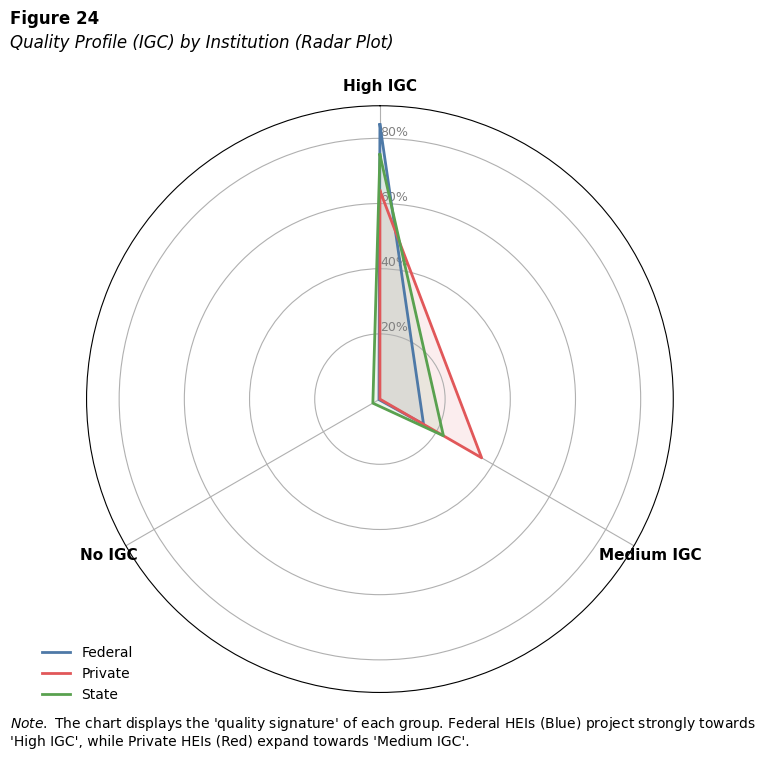

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from math import pi

# Config
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    col_igc = 'igc_categoria'
    col_inst = 'tipo_ies_corrigido'
    df = df.dropna(subset=[col_igc, col_inst])
    exclude = ['Instituto de Pesquisa', 'Outras']
    df_filtered = df[~df[col_inst].isin(exclude)].copy()
except:
    df_filtered = pd.DataFrame()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'State',
    'IES Privada': 'Private'
}
mapa_igc_en = {'IGC Alto': 'High IGC', 'IGC Médio': 'Medium IGC', 'Sem IGC': 'No IGC'}

df_filtered['inst_en'] = df_filtered[col_inst].map(mapa_inst_en)
df_filtered['igc_en'] = df_filtered[col_igc].map(mapa_igc_en)

colors_en = {'Federal': '#4e79a7', 'State': '#59a14f', 'Private': '#e15759'}

# Perfil
perfil = pd.crosstab(df_filtered['inst_en'], df_filtered['igc_en'], normalize='index') * 100
categorias_en = ['High IGC', 'Medium IGC', 'No IGC']
perfil = perfil.reindex(columns=categorias_en)

N = len(categorias_en)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

def plot_radar_igc_en():
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], categorias_en, fontsize=11, weight='bold')

    ax.set_rlabel_position(0)
    plt.yticks([20, 40, 60, 80], ["20%", "40%", "60%", "80%"], color="grey", size=9)
    plt.ylim(0, 90)

    for inst in perfil.index:
        values = perfil.loc[inst].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=inst, color=colors_en[inst])
        ax.fill(angles, values, color=colors_en[inst], alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), frameon=False)

    fig.text(0.05, 0.95, "Figure 24", fontsize=12, weight='bold')
    fig.text(0.05, 0.92, "Quality Profile (IGC) by Institution (Radar Plot)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ The chart displays the 'quality signature' of each group. "
            "Federal HEIs (Blue) project strongly towards 'High IGC', while Private HEIs (Red) expand towards 'Medium IGC'.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig24_radar_igc_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Radar IGC (EN)...")
plot_radar_igc_en()

In [19]:
import pandas as pd
import plotly.graph_objects as go

# ==============================================================================
# DADOS E FILTRAGEM
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_igc = 'igc_categoria'
col_inst = 'tipo_ies_corrigido'

# Filtro 1: Remover nulos
df = df.dropna(subset=[col_igc, col_inst])

# Filtro 2: Apenas IES Avaliáveis (Universidades/Faculdades)
exclude = ['Instituto de Pesquisa', 'Outras']
df = df[~df[col_inst].isin(exclude)].copy()

# Mapeamentos PT
mapa_inst = {
    'IES Pública Federal': 'IES Federal',
    'IES Pública Estadual': 'IES Estadual',
    'IES Privada': 'IES Privada'
}
# IGC já está ok, mas vamos garantir ordem
df['source'] = df[col_inst].map(mapa_inst)
df['target'] = df[col_igc] # 'IGC Alto', 'IGC Médio', 'Sem IGC'

# ==============================================================================
# CORES
# ==============================================================================
# Cores Institucionais
color_inst = {
    'IES Federal': '#4e79a7',   # Azul
    'IES Estadual': '#59a14f',  # Verde (Institucional)
    'IES Privada': '#e15759'    # Vermelho
}
# Cores de Qualidade (Destino)
color_igc = {
    'IGC Alto': '#2ca02c',      # Verde Forte
    'IGC Médio': '#edc948',     # Amarelo
    'Sem IGC': '#bab0ac'        # Cinza
}

# ==============================================================================
# PREPARAÇÃO SANKEY
# ==============================================================================
# Agrupar
flows = df.groupby(['source', 'target']).size().reset_index(name='value')

# Listas de Nós
sources_unique = list(color_inst.keys())
targets_unique = ['IGC Alto', 'IGC Médio', 'Sem IGC'] # Ordem forçada
all_nodes = sources_unique + targets_unique
node_indices = {label: i for i, label in enumerate(all_nodes)}

# Índices para o Plotly
source_idxs = flows['source'].map(node_indices).tolist()
target_idxs = flows['target'].map(node_indices).tolist()
values = flows['value'].tolist()

# Cores dos Nós
node_colors = []
for node in all_nodes:
    if node in color_inst:
        node_colors.append(color_inst[node])
    else:
        node_colors.append(color_igc.get(node, '#888888'))

# Cores dos Links (Com transparência)
def hex_to_rgba(hex_code, alpha=0.4):
    hex_code = hex_code.lstrip('#')
    return f'rgba({int(hex_code[0:2], 16)}, {int(hex_code[2:4], 16)}, {int(hex_code[4:6], 16)}, {alpha})'

link_colors = [hex_to_rgba(color_inst[row['source']], 0.5) for index, row in flows.iterrows()]

# ==============================================================================
# PLOTAGEM
# ==============================================================================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15, thickness=20,
        line=dict(color="white", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=source_idxs,
        target=target_idxs,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title_text="<b>Figura 25</b><br><i>Fluxo de Qualidade: Tipo de IES para Categoria IGC</i>",
    title_font_size=14, font_family="Arial", font_size=12,
    plot_bgcolor='white', paper_bgcolor='white',
    width=900, height=500,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.add_annotation(
    text="<i>Nota.</i> Espessura das faixas indica volume de projetos. Observe a convergência massiva das<br>"
         "Federais (Azul) para 'IGC Alto' e a bifurcação das Privadas (Vermelho) entre Médio e Alto.",
    xref="paper", yref="paper", x=0, y=-0.1, showarrow=False, align="left", font=dict(size=11)
)

fig.show()

In [21]:
import pandas as pd
import plotly.graph_objects as go

# Dados
try:
    df = pd.read_csv("2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv")
    col_igc = 'igc_categoria'
    col_inst = 'tipo_ies_corrigido'
    df = df.dropna(subset=[col_igc, col_inst])
    exclude = ['Instituto de Pesquisa', 'Outras']
    df = df[~df[col_inst].isin(exclude)].copy()
except:
    df = pd.DataFrame()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Federal HEI',
    'IES Pública Estadual': 'State HEI',
    'IES Privada': 'Private HEI'
}
mapa_igc_en = {
    'IGC Alto': 'High IGC',
    'IGC Médio': 'Medium IGC',
    'Sem IGC': 'No IGC'
}

df['source'] = df[col_inst].map(mapa_inst_en)
df['target'] = df[col_igc].map(mapa_igc_en)

# Cores EN
color_inst_en = {'Federal HEI': '#4e79a7', 'State HEI': '#59a14f', 'Private HEI': '#e15759'}
color_igc_en = {'High IGC': '#2ca02c', 'Medium IGC': '#edc948', 'No IGC': '#bab0ac'}

# Preparação
flows = df.groupby(['source', 'target']).size().reset_index(name='value')
sources_unique = list(color_inst_en.keys())
targets_unique = ['High IGC', 'Medium IGC', 'No IGC']
all_nodes = sources_unique + targets_unique
node_indices = {label: i for i, label in enumerate(all_nodes)}

source_idxs = flows['source'].map(node_indices).tolist()
target_idxs = flows['target'].map(node_indices).tolist()
values = flows['value'].tolist()

node_colors = []
for node in all_nodes:
    if node in color_inst_en:
        node_colors.append(color_inst_en[node])
    else:
        node_colors.append(color_igc_en.get(node, '#888888'))

def hex_to_rgba(hex_code, alpha=0.4):
    hex_code = hex_code.lstrip('#')
    return f'rgba({int(hex_code[0:2], 16)}, {int(hex_code[2:4], 16)}, {int(hex_code[4:6], 16)}, {alpha})'

link_colors = [hex_to_rgba(color_inst_en[row['source']], 0.5) for index, row in flows.iterrows()]

# Plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15, thickness=20, line=dict(color="white", width=0.5),
        label=all_nodes, color=node_colors
    ),
    link=dict(
        source=source_idxs, target=target_idxs, value=values, color=link_colors
    )
)])

fig.update_layout(
    title_text="<b>Figure 25</b><br><i>Quality Flow: HEI Type to IGC Category</i>",
    title_font_size=14, font_family="Arial", font_size=12,
    plot_bgcolor='white', paper_bgcolor='white',
    width=900, height=500,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.add_annotation(
    text="<i>Note.</i> Band thickness indicates project volume. Note the massive convergence of<br>"
         "Federal HEIs (Blue) to 'High IGC' and the bifurcation of Private HEIs (Red) between Medium and High.",
    xref="paper", yref="paper", x=0, y=-0.1, showarrow=False, align="left", font=dict(size=11)
)

fig.show()